### Оптимизация гиперпараметров

#### Цель работы

Познакомиться с оптимизацией гиперпараметров

#### Содержание работы

1. Сгенерировать датасет для задачи бинарной классификации с использованием функции make_classification.
2. Построить и оценить качество различных моделей классификации, используя метрики accuracy и F1-score.
5. Построить модель elasticnet на данных прогнозирования продаж.
6. Оптимизировать гиперпараметры данной модели с помощью поиска по сетке.

#### Методические указания

##### Простой выбор модели

Загрузим необходимые библиотеки:

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Сгенерируем матрицу признаков и вектор целей для задачи классификации. Для этого воспользуемся библиотечной функцией make_classification, которая генерирует случайное распределение по заданным параметрам. Число генерируемых точек данных зададим равным 1000, количество признаков - 5. Классов у нас  будет два.

In [43]:
from sklearn.datasets import make_classification
X, Y = make_classification(n_samples=1000, n_classes=2, n_features=5, n_redundant=0, random_state=1)

Выведем количественные параметры датаета:

In [44]:
X.shape, Y.shape

((1000, 5), (1000,))

В датасете описаны 1000 объектов и у каждого есть 5 признаков. 

Разделим данные на обучающую и тестовую части:

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

Выведем количественные параметры тестовой и обучающей выборки:

In [46]:
X_train.shape, Y_train.shape

((800, 5), (800,))

In [47]:
X_test.shape, Y_test.shape

((200, 5), (200,))

Можем приступать к созданию и обучению модели. Импортируем нужные объекты из библиотеки scikit-learn. В данном случае мы будем импортировать модели классифиции.

In [48]:
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import SGDClassifier


Построение различных моделей классификации

In [49]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net", "AdaBoost",
         "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(n_estimators=100),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2")]

Необходимо сравнить модели друг с другом и выбрать наиболее точные. Обучим модель, примените модель к тестовым данным и запишите показатели точности.

In [50]:
scores = []
for name, clf in zip(names, classifiers):
    clf.fit(X_train, Y_train)
    score = clf.score(X_test, Y_test)
    scores.append(score)

Анализ производительности модели

In [51]:
import pandas as pd
import seaborn as sns

Сформируем DataFrame для наглядного отображения показателя точности

In [52]:
df = pd.DataFrame()
df['name'] = names
df['score'] = scores
df.sort_values(by=["score"], ascending=False, inplace=True)
df

,name,score
4,Gaussian_Process,0.860
6,Decision_Tree,0.860
8,Random_Forest,0.860
11,Naive_Bayes,0.860
9,Neural_Net,0.855
1,Linear_SVM,0.850
12,QDA,0.845
10,AdaBoost,0.840
2,Polynomial_SVM,0.830
3,RBF_SVM,0.830


Добавление цветов во фрейм данных

In [53]:
cm = sns.light_palette("green", as_cmap=True)
s = df.style.background_gradient(cmap=cm)
s

,name,score
4,Gaussian_Process,0.860000
6,Decision_Tree,0.860000
8,Random_Forest,0.860000
11,Naive_Bayes,0.860000
9,Neural_Net,0.855000
1,Linear_SVM,0.850000
12,QDA,0.845000
10,AdaBoost,0.840000
2,Polynomial_SVM,0.830000
3,RBF_SVM,0.830000


Мы также можем создать график результатов оценки модели и сравнить расхождение средней точность каждой модели. 
Так же для визуализации можно использовать sns.set

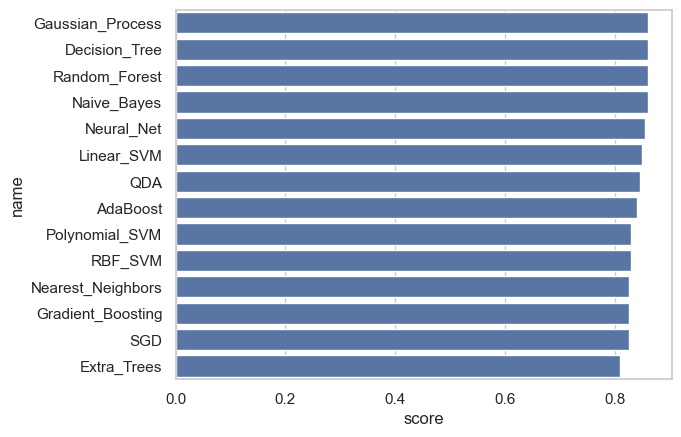

In [54]:
sns.set(style="whitegrid")
ax = sns.barplot(y="name", x="score", data=df)

Рассмотрим как мы можем оптимизировать методы. Для этого выберем метод Grid Search. И раасмотрим пример на основе данных затрат на рекламу. 

Рассмотрим реализацию для оптимизации производительности метода машинного обучения с помощью Grid Search.

Настройка гиперпараметров важна для правильной работы моделей машинного обучения (ML). Grid Search, является базовым методом для оптимизации гиперпараметров. Данный метод рассматривает некоторые комбинации гиперпараметров и выбирает ту, которая дает более низкий балл ошибки. 

##### Поиск по сетке

Мы можем перебирать комбинации гиперпараметров с помощью поиска по сетке (grid). Линейные модели достаточно просты, и у них даже есть свои специализированные версии поиска значений параметров. Но также можно использовать обобщённый метод поиска по сетке - grid search. Этот метод применим для *любой* модели в sklearn, и он пригодится нам позже для более сложных моделей.

Мы будем использовать данные из книги ISLR (Introduction to Statistical Learning: With Applications in R). Это будут продажи определённого продукта (в тысячах единиц), как функция от бюджета рекламы на ТВ, радио и в газетах (в тысячах долларов). Наша задача исследовать на сколько реклама влияет на продажу товаров. Если мы выясним что никакой связи нет, то тогда не стоит тратить деньги на рекламу. Мы хотели бы увидеть чем больше тратится денег на рекламу тем больше продаются товары.

In [55]:
df = pd.read_csv("data/Advertising.csv")

Посмотрим на данные, видим кол-во денег, потраченное на рекламу, отдельно на TV, radio, newspaper, за некоторый период времени, например за неделю. Sales объем продаж товаров, за тот же самый период времени.

In [56]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Далее разобьем данные на признаки и целевую переменную. Признаки это все колонки кроме целевой переменной, один из способов быстро получить все эти колонки df.drop('sales',axis=1). Все признаки измеряются в одних и тех же единицах измерения. 

Библиотека Python sklearn предлагает нам функцию StandardScaler() для стандартизации значений данных в стандартный формат. В соответствии с приведенным ниже синтаксисом мы изначально создаем объект функции StandardScaler(). Далее используем fit_transform() вместе с присвоенным объектом для преобразования данных и их стандартизации. 

In [57]:
## Создаём X и y
X = df.drop('sales',axis=1)
y = df['sales']

# Разбиение на обучающий и тестовый наборы - TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Масштабирование данных (SCALE)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

ElasticNet это популярный тип регуляризованной линейной регрессии, который сочетает в себе два популярных штрафа, а именно штрафные функции L1 и L2.

В модели ElasticNet есть два парамера L1_ratio он задает соотношение между Lasso регрессией и Ridg регрессией, второй параметр alfa - отвечает за то на сколько сильно мы применяем штрафное слагаемое для регуляризации. Задача состоит в том что бы найти такие параметры alfa и L1_ratio которые будут оптимальными. 

In [58]:
from sklearn.linear_model import ElasticNet

In [59]:
help(ElasticNet)

Help on class ElasticNet in module sklearn.linear_model._coordinate_descent:

class ElasticNet(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, sklearn.linear_model._base.LinearModel)
 |  ElasticNet(alpha=1.0, *, l1_ratio=0.5, fit_intercept=True, precompute=False, max_iter=1000, copy_X=True, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')
 |
 |  Linear regression with combined L1 and L2 priors as regularizer.
 |
 |  Minimizes the objective function:
 |
 |  .. math::
 |
 |      \frac{1}{2 n_{\rm samples}} \cdot \|y - X w\|_2^2
 |      + \alpha \cdot {\rm l1\_{ratio}} \cdot \|w\|_1
 |      + 0.5 \cdot \alpha \cdot (1 - {\rm l1\_{ratio}}) \cdot \|w\|_2^2
 |
 |  If you are interested in controlling the L1 and L2 penalty
 |  separately, keep in mind that this is equivalent to:
 |
 |  .. math::
 |
 |      a \cdot \|w\|_1 + 0.5 \cdot b \cdot \|w\|_2^2
 |
 |  where:
 |
 |  .. math::
 |
 |      \alpha = a + b, \quad {\rm l1\_{ratio}} = \frac{a}{a 

Значения гиперпараметров будем искать используя готовый класс Grid SearchCV.


Этот поиск состоит из следующих составляющих:

* функция оценки - estimator (рregressor или classifier, например sklearn.svm.SVC());
* пространство параметров;
* метод поиска или сэмплирования кандидатов;
* схема кросс-валидации
* функция оценки (score function).

Cоздадим экземпляр модели ElasticNet() со значениями по умолчанию.

In [60]:
base_elastic_model = ElasticNet()

Создаем переменную param_grid это будет словарь в котором укажем возможные значения гиперпараметров которые хотим исследовать


In [61]:
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1, .5, .7, .9, .95, .99, 1]}

Мы создали сетку с возможными значениями гиперпараметров. 

Далее выполним поиск по сетке, для этого импортируем GridSearchCV


In [62]:
from sklearn.model_selection import GridSearchCV

Укажем параметры для GridSearchCV. Существуют следующие параметры estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)


In [63]:
# число verbose выбирайте сами
grid_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=2)

Следубщий шаг обучить модель с помощью метода fit, подаем на вход обучающий набор данных. Метод fit пройдет в цикле по всем комбинациям гиперпараметров, для каждой комбинации гиперпарамеиров выполнит кросс валидацию с разбиение данных на k частей, выберет наилучшие значения гиперпараметров по указанной сетрике а именно neg_mean_squared_error и вернет на выходе обученную модель

In [64]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.1,

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 1, ...], 'l1_ratio': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

Посмотреть какая модель получилась наилучшая:

In [65]:
grid_model.best_estimator_

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Видим ElasticNet с параметрами. Это наилучшая комбинация гиперпараметров

Если параметры нас устраивают переходим к созданию модели

In [66]:
y_pred = grid_model.predict(X_test)

И вычисляем метрики

In [67]:
from sklearn.metrics import mean_squared_error

In [68]:
mean_squared_error(y_test,y_pred)

2.387342642087474

Получили финальную оценку работы нашей модели

### Контрольные вопросы

**1. Зачем нужно производить оптимизацию гиперпараметров?**

Гиперпараметры — это настройки модели, которые задаются **до обучения** (в отличие от параметров, которые модель изучает сама). Оптимизация нужна потому, что от правильно подобранных гиперпараметров напрямую зависит качество модели. Модель с плохими гиперпараметрами может либо недообучаться (слишком простая), либо переобучаться (слишком сложная). Оптимизация позволяет найти наилучший баланс.

**2. В чём заключается процесс оптимизации гиперпараметров?**

Процесс заключается в **переборе различных комбинаций гиперпараметров** с оценкой качества каждой комбинации. Обычно это делается через кросс-валидацию: для каждого набора гиперпараметров модель обучается на разных разбиениях данных, вычисляется средняя метрика, и выбирается комбинация с лучшим результатом.

**3. В чем достоинства и недостатки метода GridSearchCV?**

**Достоинства:**
- Гарантированно находит лучшую комбинацию из заданной сетки (полный перебор)
- Прост в использовании, встроен в sklearn
- Позволяет использовать кросс-валидацию внутри себя

**Недостатки:**
- **Проклятие размерности** — при добавлении новых гиперпараметров или увеличении их возможных значений число комбинаций растёт экспоненциально
- Может быть очень медленным, особенно на больших данных
- Требует заранее задать диапазоны, которые могут оказаться неудачными

**4. Какие еще стратегии оптимизации гиперпараметров существуют?**

- **RandomizedSearchCV** — случайный поиск. Перебирает не все комбинации, а заданное количество случайных. Гораздо быстрее GridSearch при большом пространстве.
- **Bayesian Optimization** — использует вероятностную модель для умного выбора следующих комбинаций (библиотеки: `scikit-optimize`, `hyperopt`, `optuna`).
- **HalvingGridSearchCV / HalvingRandomSearchCV** — сначала быстро отсеивает плохие комбинации на малом количестве данных, затем лучшие дообучает.
- **Ручная настройка** — опытный специалист подбирает параметры вручную, основываясь на кривых обучения и валидации.

**5. Почему при использовании GridSearchCV не нужна валидационная выборка?**

Потому что **кросс-валидация** внутри `GridSearchCV` выполняет роль валидации. Данные разбиваются на K фолдов, и каждая комбинация гиперпараметров оценивается на всех фолдах по очереди. Это даёт более стабильную и несмещённую оценку, чем одна фиксированная валидационная выборка. Отдельная валидационная выборка нужна только если вы хотите сохранить совсем "чистый" тестовый набор для финальной оценки после выбора модели.